# Stance Classifier

Experimental notebook for developing, training, and testing the classification model for the catcher stance.

In [353]:
import pandas as pd
import numpy as np
import os
import ast
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
# Uncomment when using Google Colab
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [355]:
# Load the dataset
DATASET_PATH = "./drive/MyDrive/keypoints-labeled.csv"
df = pd.read_csv(DATASET_PATH)

In [356]:
# Drop rows where features is missing
df = df.dropna(subset=["features"]).copy()

# Also optionally drop blank strings
df = df[df["features"].astype(str).str.strip() != ""].copy()

# Convert stringified list -> numpy array
df["features"] = df["features"].apply(ast.literal_eval)
df["features"] = df["features"].apply(lambda x: np.array(x, dtype=np.float32))

# Stack into X matrix
X = np.stack(df["features"].values)

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["choice"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", label_encoder.classes_)

X shape: (2489, 238)
y shape: (2489,)
Classes: ['Knee-down Left' 'Knee-down Right' 'Squat']


In [357]:
# Create the train, test, and validation sets

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1742, 238) (1742,)
Val: (373, 238) (373,)
Test: (374, 238) (374,)


In [358]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import joblib

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 30
MODEL_OUTPUT_PATH = "catcher_stance/models/catcher_stance_mlp.pt"
LABEL_ENCODER_PATH = "catcher_stance/models/label_encoder.pkl"

import os
os.makedirs("catcher_stance/models", exist_ok=True)

In [359]:
class CatcherDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [360]:
train_dataset = CatcherDataset(X_train, y_train)
val_dataset = CatcherDataset(X_val, y_val)
test_dataset = CatcherDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [361]:
class CatcherMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [362]:
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

model = CatcherMLP(input_dim=input_dim, num_classes=num_classes).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [363]:
def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.set_grad_enabled(train_mode):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc

In [364]:
EPOCHS = 50
PATIENCE = 10
best_val_loss = float("inf")
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), MODEL_OUTPUT_PATH)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered after epoch {epoch+1}")
        break

Epoch 1/50 | train_loss=0.7657 train_acc=0.7239 | val_loss=0.6345 val_acc=0.6032
Epoch 2/50 | train_loss=0.6552 train_acc=0.7445 | val_loss=0.4884 val_acc=0.7828
Epoch 3/50 | train_loss=0.6019 train_acc=0.7732 | val_loss=0.5308 val_acc=0.7560
Epoch 4/50 | train_loss=0.5608 train_acc=0.7910 | val_loss=0.4685 val_acc=0.7587
Epoch 5/50 | train_loss=0.5061 train_acc=0.8014 | val_loss=0.4868 val_acc=0.7855
Epoch 6/50 | train_loss=0.4756 train_acc=0.8111 | val_loss=0.4819 val_acc=0.7936
Epoch 7/50 | train_loss=0.4468 train_acc=0.8238 | val_loss=0.4560 val_acc=0.7775
Epoch 8/50 | train_loss=0.4299 train_acc=0.8180 | val_loss=0.4556 val_acc=0.8257
Epoch 9/50 | train_loss=0.4115 train_acc=0.8490 | val_loss=0.4912 val_acc=0.7426
Epoch 10/50 | train_loss=0.3585 train_acc=0.8542 | val_loss=0.4733 val_acc=0.8070
Epoch 11/50 | train_loss=0.3200 train_acc=0.8766 | val_loss=0.5401 val_acc=0.7373
Epoch 12/50 | train_loss=0.3383 train_acc=0.8548 | val_loss=0.4469 val_acc=0.8231
Epoch 13/50 | train_loss=

In [365]:
# Load best model before final test evaluation
best_model = CatcherMLP(input_dim=input_dim, num_classes=num_classes).to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_OUTPUT_PATH, map_location=DEVICE))
best_model.eval()

CatcherMLP(
  (net): Sequential(
    (0): Linear(in_features=238, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.1, inplace=False)
    (11): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [366]:
def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            logits = model(X_batch)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    return np.array(all_labels), np.array(all_preds)

Test Accuracy: 0.8475935828877005

Classification Report:
                 precision    recall  f1-score   support

 Knee-down Left       0.50      0.75      0.60        57
Knee-down Right       0.95      0.87      0.91       315
          Squat       0.00      0.00      0.00         2

       accuracy                           0.85       374
      macro avg       0.48      0.54      0.50       374
   weighted avg       0.88      0.85      0.86       374



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


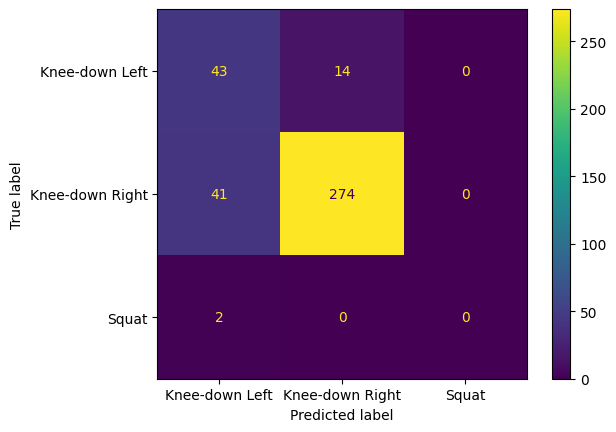

In [367]:
y_true, y_pred = get_predictions(best_model, test_loader)

test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", test_acc)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

cm_display.plot()
plt.show()

In [368]:
# Save label encoder too
joblib.dump(label_encoder, LABEL_ENCODER_PATH)

# Optional: save metrics/history
joblib.dump(history, "catcher_stance/models/training_history.pkl")

print("Saved model to:", MODEL_OUTPUT_PATH)
print("Saved label encoder to:", LABEL_ENCODER_PATH)

Saved model to: catcher_stance/models/catcher_stance_mlp.pt
Saved label encoder to: catcher_stance/models/label_encoder.pkl
